# OpenArt — Exploratory Data Analysis

Corpus snapshot: `data/raw/opportunities.csv` 

In [262]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid")

REPO_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(REPO_ROOT, "dataset", "opportunities.csv")

In [263]:
df = pd.read_csv(DATA_PATH)
df.shape

(479, 37)

## Data cleaning summary

This corpus was cleaned upstream by an automated pipeline (`src/processing/`), not here — see `workflow.MD` for the full design rationale and `ANNOTATION_GUIDELINES.md` for annotation-specific caveats (a small number of excluded rows). The cells below don't redo that work; they just show what it did, since the raw and cleaned columns both survive side by side in `dataset/opportunities.csv` for exactly this purpose.

Pipeline stages: deadline parsing (locale-specific bugs, PDF-extraction artifacts, date-range year inheritance) → content-based deduplication → categorical canonicalization (`discipline`/`opportunity_type`/`career_stage`/`country`, translated then mapped onto a fixed vocabulary) → structured extraction (`funding`/`application_fee` → category + amount + currency + period) → placeholder-leak cleanup (a few rows had a literal `"null"`/`"[not present in provided text]"` string instead of an actual null).

In [264]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          479 non-null    str    
 1   source                      479 non-null    str    
 2   source_url                  479 non-null    str    
 3   application_url             315 non-null    str    
 4   organisation                479 non-null    str    
 5   description                 479 non-null    str    
 6   discipline                  474 non-null    str    
 7   opportunity_type            479 non-null    str    
 8   country                     437 non-null    str    
 9   city                        208 non-null    str    
 10  funding                     389 non-null    str    
 11  application_fee             35 non-null     str    
 12  career_stage                117 non-null    str    
 13  description_en              479 non-null    st

In [265]:
df.isna().sum()

id                              0
source                          0
source_url                      0
application_url               164
organisation                    0
description                     0
discipline                      5
opportunity_type                0
country                        42
city                          271
funding                        90
application_fee               444
career_stage                  362
description_en                  0
discipline_en                   5
opportunity_type_en             0
career_stage_en               362
country_en                     42
city_en                       271
discipline_canonical            0
opportunity_type_canonical      0
career_stage_canonical          0
country_canonical               0
funding_components              0
funding_extracted_at           90
application_fee_has_fee       444
application_fee_amount_min    464
application_fee_amount_max    464
application_fee_currency      464
language      

In [266]:
features = ["id", "language", "title_en", "requirements_text_en", "deadline_date", "source", "organisation", "description_en", "country_canonical", "city_en", "funding", "funding_components", "application_fee_has_fee", "discipline_canonical", "opportunity_type_canonical", "career_stage_canonical"]

In [267]:
exploration_df = df[features]

In [268]:
exploration_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          479 non-null    str   
 1   language                    479 non-null    str   
 2   title_en                    479 non-null    str   
 3   requirements_text_en        479 non-null    str   
 4   deadline_date               359 non-null    str   
 5   source                      479 non-null    str   
 6   organisation                479 non-null    str   
 7   description_en              479 non-null    str   
 8   country_canonical           479 non-null    str   
 9   city_en                     208 non-null    str   
 10  funding                     389 non-null    str   
 11  funding_components          479 non-null    str   
 12  application_fee_has_fee     35 non-null     object
 13  discipline_canonical        479 non-null    str   
 14  oppor

In [269]:
exploration_df.isna().sum()

id                              0
language                        0
title_en                        0
requirements_text_en            0
deadline_date                 120
source                          0
organisation                    0
description_en                  0
country_canonical               0
city_en                       271
funding                        90
funding_components              0
application_fee_has_fee       444
discipline_canonical            0
opportunity_type_canonical      0
career_stage_canonical          0
dtype: int64

In [270]:
exploration_df.tail(5)

,id,language,title_en,requirements_text_en,deadline_date,source,organisation,description_en,country_canonical,city_en,funding,funding_components,application_fee_has_fee,discipline_canonical,opportunity_type_canonical,career_stage_canonical
474,national_culture_fund_bulgaria_cb83dc97ab66,bg,"Targeted Support ""Creative Europe"" 2nd session",Eligible applicants: Legal entities,2026-09-24,national_culture_fund_bulgaria,Национален фонд „Култура“,The program provides financial support for projects approved for funding und...,[],NaN,Програмата предоставя финансова подкрепа на проекти,"[{'category': 'Other/Unspecified Support', 'amount_min': None, 'amount_max':...",NaN,['Multidisciplinary'],['Grant/Funding'],[]
475,national_culture_fund_bulgaria_d14ee5d6a3ee,bg,TARGETED SUPPORT PROGRAM “CREATIVE EUROPE” FIRST AND SECOND SESSION 2026,Bulgarian cultural organizations (legal entities) with a registered office i...,2026-06-26,national_culture_fund_bulgaria,Национален фонд „Култура“,The program provides financial support for projects approved for funding und...,[],NaN,• Общ размер на финансирането на програмата: 5 % от общия бюджет за програми...,"[{'category': 'Grant/Stipend', 'amount_min': None, 'amount_max': None, 'curr...",NaN,['Multidisciplinary'],['Grant/Funding'],[]
476,royal_court_theatre_344bc55515e5,en,Submit Your Play,"Anyone writing in English, from the UK and around the world, can send us a p...",NaN,royal_court_theatre,Royal Court Theatre,"We’re dedicated to finding the most exciting new plays, underpinned by our c...","['United Kingdom', 'International/Global']",NaN,NaN,[],NaN,['Theatre'],['Open Call'],[]
477,statens_vaerksteder_for_kunst_a543d1a88fd3,en,Apply for residency,"At the Danish Art Workshops, professional artists, designers, crafts people ...",2027-11-24,statens_vaerksteder_for_kunst,Danish Art Workshops (SVFK),"At the Danish Art Workshops, professional artists, designers, crafts people ...",['Denmark'],NaN,All residencies at SVFK are funded as scholarships from the Danish State as ...,"[{'category': 'Grant/Stipend', 'amount_min': None, 'amount_max': None, 'curr...",False,"['Visual Arts', 'Craft', 'Design/Architecture']",['Residency'],['Established/Professional']
478,wiels_brussels_fcbabea29454,en,A residency at WIELS,This call is intended for Belgian artists or artists residing in Belgium who...,2027-05-24,wiels_brussels,WIELS,"an international residency programme focused on artistic practice, critical ...",['Belgium'],Brussels,Selected artists are offered a six-month residency (January–June or July–Dec...,"[{'category': 'Grant/Stipend', 'amount_min': None, 'amount_max': None, 'curr...",NaN,['Multidisciplinary'],['Residency'],[]


In [271]:
discipline_counts = exploration_df["discipline_canonical"].fillna("(not stated)").value_counts()
print(discipline_counts)
print(f"\n{df['discipline'].isna().sum()} entries ({df['discipline'].isna().mean():.1%}) have no stated discipline")

discipline_canonical
['Multidisciplinary']                                                               80
['Visual Arts']                                                                     70
['Literature/Writing']                                                              40
['Music']                                                                           35
['Other/Non-Arts']                                                                  24
                                                                                    ..
['Cultural Heritage', 'Other/Non-Arts']                                              1
['Literature/Writing', 'Cultural Heritage']                                          1
['Cultural Heritage', 'Craft']                                                       1
['Visual Arts', 'Music', 'Literature/Writing', 'Theatre', 'Film/Video', 'Dance']     1
['Visual Arts', 'Craft', 'Design/Architecture']                                      1
Name: count, Length: 1

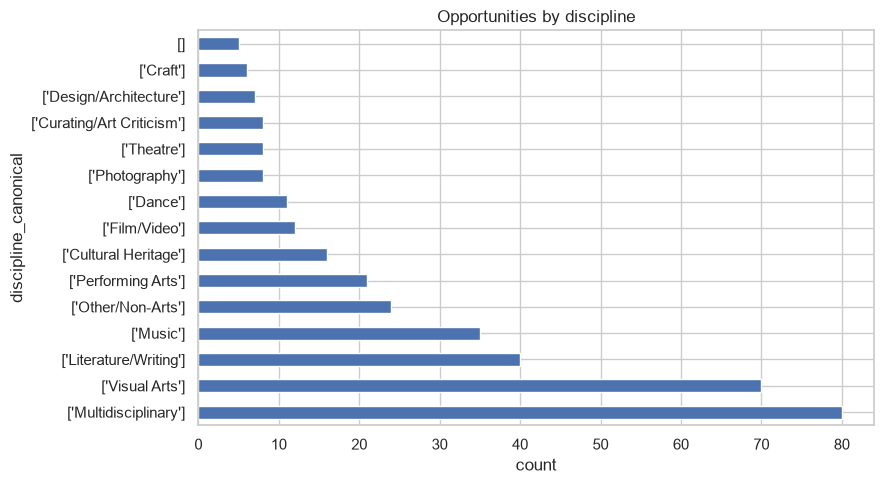

In [272]:
discipline_counts.head(15).plot(kind="barh", title="Opportunities by discipline")
plt.xlabel("count")
plt.tight_layout()
plt.show()

country_canonical
['Slovakia']                                                                                                                                                           59
['Belgium']                                                                                                                                                            53
[]                                                                                                                                                                     52
['Norway']                                                                                                                                                             43
['Germany']                                                                                                                                                            34
['Netherlands']                                                                                                                     

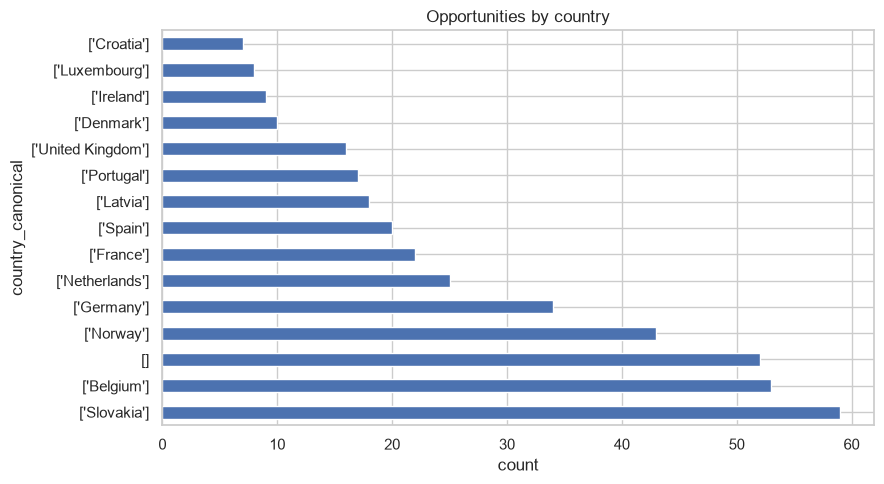

In [273]:
country_counts = exploration_df["country_canonical"].fillna("(not stated)").value_counts()
print(country_counts)
print(f"\n{exploration_df["country_canonical"].nunique()} distinct countries represented")
 
country_counts.head(15).plot(kind="barh", title="Opportunities by country")
plt.xlabel("count")
plt.tight_layout()
plt.show()

In [274]:
print("By source:")
print(exploration_df["source"].value_counts())

By source:
source
kunsten_be_flanders                    119
fpu_slovakia                            59
kulturdirektoratet_norway               41
mondriaan_fund                          18
vkkf_konkursu_grafiks                   18
dgartes_portugal                        15
kunststiftung_nrw                       13
matadero_madrid                         12
deutscher_uebersetzerfonds              12
arts_council_wales                      11
villa_arson                             10
cite_internationale_des_arts             9
kunst_dk_denmark                         9
creative_ireland                         9
nordic_culture_point                     8
ekkomed_greece                           8
european_cultural_foundation             7
focuna_luxembourg                        7
institut_francais_programs               7
min_kulture_croatia                      7
gasworks_london                          6
national_culture_fund_bulgaria           6
bmwkms_austria                      

Funded (funding field populated): 389 (81.2%)


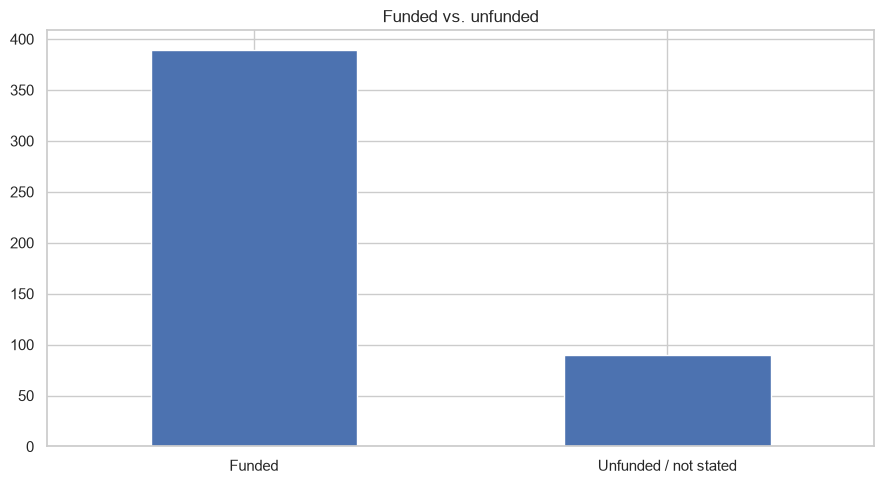

In [275]:
has_funding = exploration_df["funding"].notna() & (exploration_df["funding"].astype(str).str.strip() != "")
print(f"Funded (funding field populated): {has_funding.sum()} ({has_funding.mean():.1%})")

pd.Series({"Funded": has_funding.sum(), "Unfunded / not stated": (~has_funding).sum()}).plot(
    kind="bar", title="Funded vs. unfunded", rot=0
)
plt.tight_layout()
plt.show()

  RESIDENCE/NATIONALITY     present in  137 entries (28.6%)
  AGE                       present in  185 entries (38.6%)
  DISCIPLINE                present in   81 entries (16.9%)
  CAREER_STAGE              present in   96 entries (20.0%)
  EDUCATION                 present in   51 entries (10.6%)

  Entries with NO matched eligibility keyword at all: 141 (29.4%)
  -> this is your rough preview of how big the NONE class will be


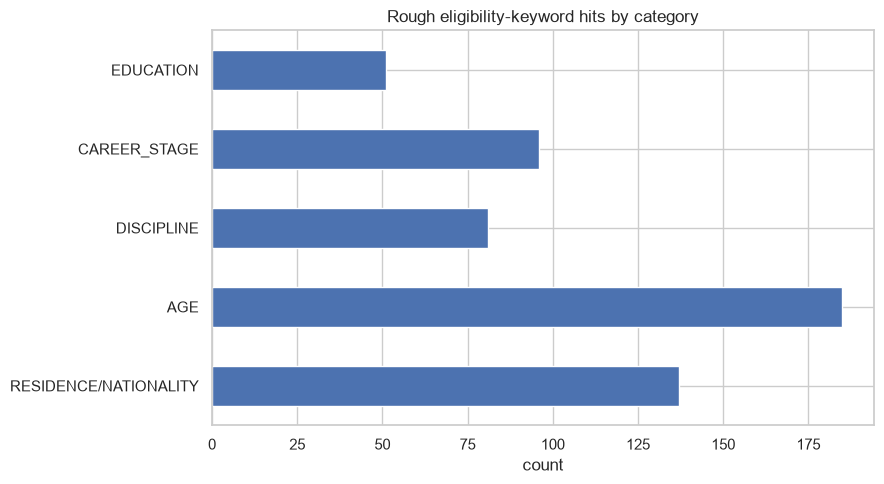

In [276]:
ELIGIBILITY_KEYWORDS = {
    "RESIDENCE/NATIONALITY": ["resident", "citizen", "nationality", "based in", "resid"],
    "AGE": ["age", "years old", "born after", "aged"],
    "DISCIPLINE": ["discipline", "medium", "practice in", "visual art", "sculpture", "painting"],
    "CAREER_STAGE": ["emerging", "early-career", "established", "professional artist"],
    "EDUCATION": ["degree", "enrolled", "student", "graduate"],
}
 
text_col = exploration_df["requirements_text_en"] if "requirements_text_en" in df.columns else df["requirements_text"]
text_lower = text_col.fillna("").str.lower()
 
keyword_hits = {}
for label, keywords in ELIGIBILITY_KEYWORDS.items():
    mask = text_lower.str.contains("|".join(keywords), regex=True)
    keyword_hits[label] = mask.sum()
    print(f"  {label:25s} present in {mask.sum():4d} entries ({mask.mean():.1%})")
 
any_keyword = text_lower.str.contains("|".join(sum(ELIGIBILITY_KEYWORDS.values(), [])), regex=True)
none_count = (~any_keyword).sum()
print(f"\n  Entries with NO matched eligibility keyword at all: {none_count} ({(~any_keyword).mean():.1%})")
print("  -> this is your rough preview of how big the NONE class will be")
 
pd.Series(keyword_hits).plot(kind="barh", title="Rough eligibility-keyword hits by category")
plt.xlabel("count")
plt.tight_layout()
plt.show()

In [277]:
exploration_df.columns

Index(['id', 'language', 'title_en', 'requirements_text_en', 'deadline_date',
       'source', 'organisation', 'description_en', 'country_canonical',
       'city_en', 'funding', 'funding_components', 'application_fee_has_fee',
       'discipline_canonical', 'opportunity_type_canonical',
       'career_stage_canonical'],
      dtype='str')

discipline_canonical  (other)  ['Cultural Heritage']  ['Film/Video']  \
country_canonical                                                      
(other)                    69                      5               6   
['Belgium']                21                      0               0   
['France']                 10                      0               1   
['Germany']                 5                      0               0   
['Netherlands']             9                      2               0   
['Norway']                  9                      4               0   
['Slovakia']               23                      5               0   
['Spain']                   9                      0               1   
[]                         26                      0               4   

discipline_canonical  ['Literature/Writing']  ['Multidisciplinary']  \
country_canonical                                                     
(other)                                    9                     

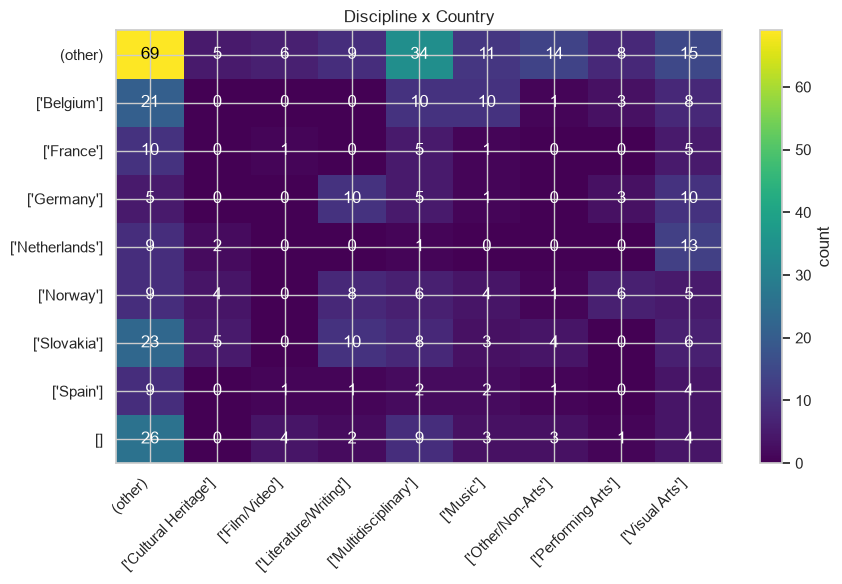

In [278]:
top_disciplines = exploration_df["discipline_canonical"].fillna("(not stated)").value_counts().head(8).index
top_countries = exploration_df["country_canonical"].fillna("(not stated)").value_counts().head(8).index
 
cross = pd.crosstab(
    exploration_df["country_canonical"].fillna("(not stated)").where(exploration_df["country_canonical"].isin(top_countries), "(other)"),
    exploration_df["discipline_canonical"].fillna("(not stated)").where(exploration_df["discipline_canonical"].isin(top_disciplines), "(other)"),
)
print(cross)
 
plt.figure(figsize=(9, 6))
plt.imshow(cross.values, aspect="auto", cmap="viridis")
plt.xticks(range(len(cross.columns)), cross.columns, rotation=45, ha="right")
plt.yticks(range(len(cross.index)), cross.index)
plt.colorbar(label="count")
plt.title("Discipline x Country")
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        plt.text(j, i, cross.values[i, j], ha="center", va="center",
                  color="white" if cross.values[i, j] < cross.values.max() / 2 else "black")
plt.tight_layout()
plt.show()


opportunity_type_canonical
['Grant/Funding']                          238
['Residency']                               81
['Open Call']                               65
['Other']                                   36
['Competition/Prize']                       29
['Workshop/Training']                        8
['Fellowship']                               6
['Commission']                               5
['Grant/Funding', 'Open Call']               3
['Grant/Funding', 'Residency']               1
['Open Call', 'Other']                       1
['Exhibition/Showcase']                      1
['Open Call', 'Residency']                   1
['Residency', 'Grant/Funding', 'Other']      1
['Grant/Funding', 'Fellowship']              1
['Exhibition/Showcase', 'Residency']         1
[]                                           1
Name: count, dtype: int64


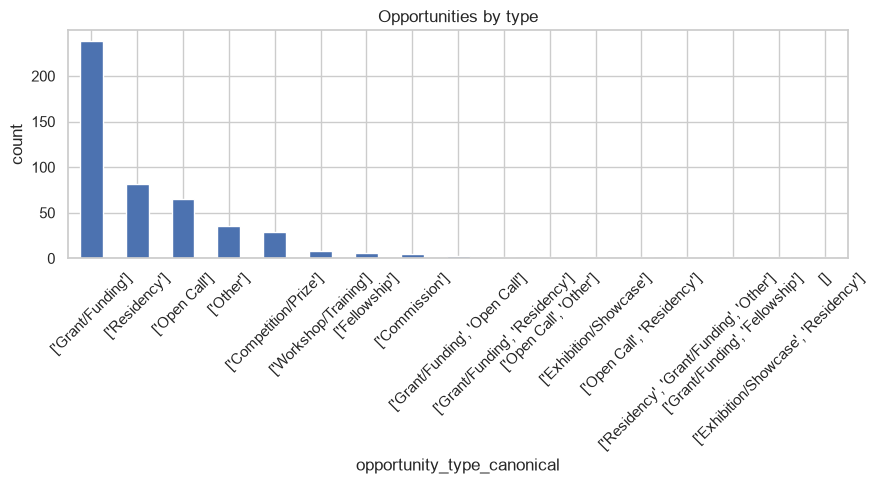

In [279]:
if "opportunity_type" in df.columns:
    type_counts = exploration_df["opportunity_type_canonical"].fillna("(not stated)").value_counts()
    print(type_counts)
 
    type_counts.plot(kind="bar", title="Opportunities by type", rot=45)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("No `opportunity_type` column found.")

---

## Act I — What is this corpus?

Every number in the sections below inherits whatever's true about the corpus itself — so before describing *what the opportunities look like*, it's worth being explicit about *what this dataset is*: how big, how many independent sources it draws from, what languages it spans, and where it's likely skewed. Naming these limits up front is what makes the descriptive claims in Act II trustworthy, rather than something a reviewer has to catch.

In [280]:
# Shared chart style for Acts I-III: a fixed categorical order (assigned by
# identity, never re-cycled per chart) and a single-hue sequential ramp for
# magnitude encodings (heatmaps). Keeps every new chart visually consistent.
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import ast

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list("sequential_blue", ["#cde2fb", "#3987e5", "#0d366b"])
MUTED_INK = "#898781"
GRIDLINE = "#e1e0d9"


def style_axis(ax, horizontal=False):
    ax.grid(axis="x" if horizontal else "y", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRIDLINE)
    ax.tick_params(colors=MUTED_INK, labelsize=9)
    return ax

In [281]:
deadline_dates = pd.to_datetime(df["deadline_date"], errors="coerce")

print(f"{'Opportunities in corpus':32s} {len(df):>6,}")
print(f"{'Independent sources':32s} {df['source'].nunique():>6,}")
print(f"{'Source languages':32s} {df['language'].nunique():>6,}")
print(f"{'Deadlines span':32s} {deadline_dates.min().date()} -> {deadline_dates.max().date()}")
print(f"{'Share of deadlines in 2026':32s} {(deadline_dates.dt.year == 2026).mean():>6.0%}   <- a live corpus, not a historical archive")

Opportunities in corpus             479
Independent sources                  51
Source languages                     11
Deadlines span                   2022-09-11 -> 2029-11-30
Share of deadlines in 2026          58%   <- a live corpus, not a historical archive


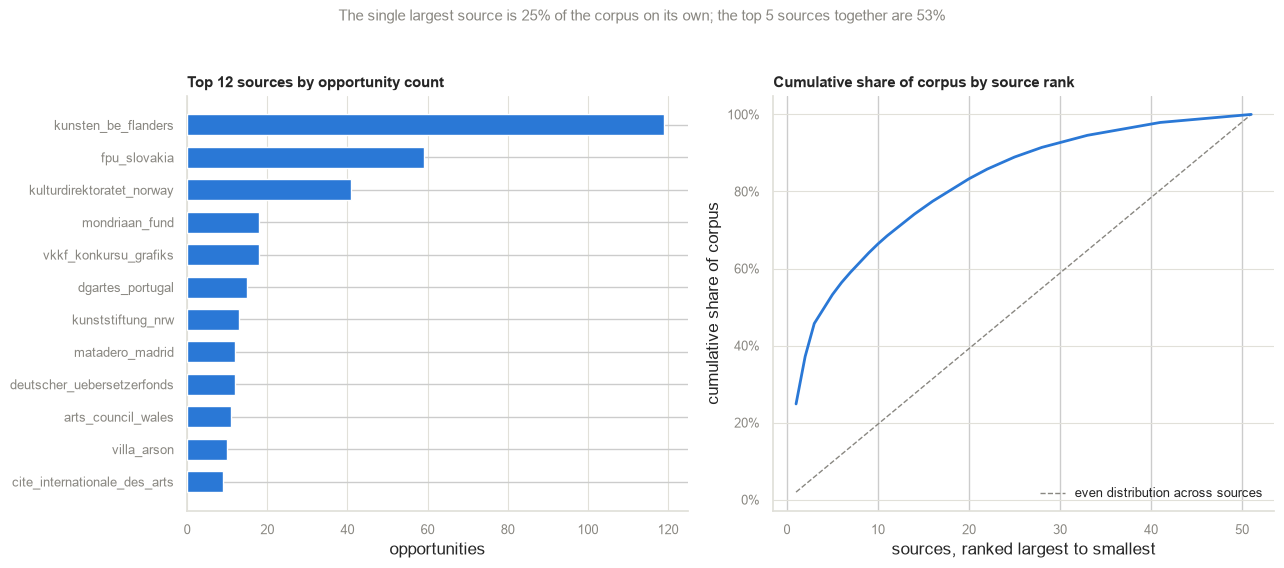

In [282]:
source_counts = df["source"].value_counts()
cum_share = source_counts.cumsum() / source_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

top_n = 12
axes[0].barh(source_counts.head(top_n).index[::-1], source_counts.head(top_n).values[::-1],
             color=CATEGORICAL[0], height=0.65, zorder=3)
axes[0].set_title(f"Top {top_n} sources by opportunity count", loc="left", fontsize=11, fontweight="bold")
axes[0].set_xlabel("opportunities")
style_axis(axes[0], horizontal=True)

rank = range(1, len(cum_share) + 1)
axes[1].plot(rank, cum_share.values, color=CATEGORICAL[0], linewidth=2, zorder=3)
axes[1].plot([1, len(cum_share)], [1 / len(cum_share), 1], color=MUTED_INK, linewidth=1,
             linestyle="--", zorder=2, label="even distribution across sources")
axes[1].set_title("Cumulative share of corpus by source rank", loc="left", fontsize=11, fontweight="bold")
axes[1].set_xlabel("sources, ranked largest to smallest")
axes[1].set_ylabel("cumulative share of corpus")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].legend(frameon=False, fontsize=9, loc="lower right")
style_axis(axes[1])

top_source_share = source_counts.iloc[0] / source_counts.sum()
top5_share = source_counts.head(5).sum() / source_counts.sum()
fig.suptitle(
    f"The single largest source is {top_source_share:.0%} of the corpus on its own; "
    f"the top 5 sources together are {top5_share:.0%}",
    fontsize=10.5, color=MUTED_INK, y=1.03,
)
plt.tight_layout()
plt.show()

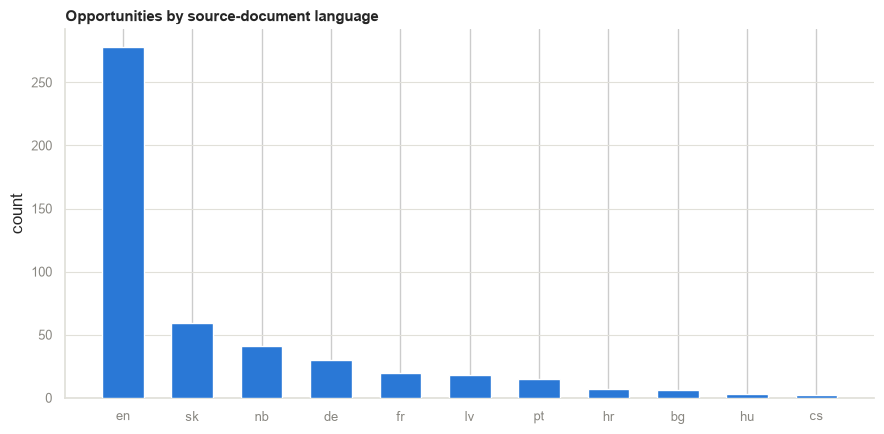

42% of source documents are NOT English and rely on the *_en translation columns before any downstream NLP touches them.


In [283]:
lang_counts = df["language"].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(lang_counts.index, lang_counts.values, color=CATEGORICAL[0], width=0.6, zorder=3)
ax.set_title("Opportunities by source-document language", loc="left", fontsize=11, fontweight="bold")
ax.set_ylabel("count")
style_axis(ax)
plt.tight_layout()
plt.show()

non_en_share = (df["language"] != "en").mean()
print(f"{non_en_share:.0%} of source documents are NOT English and rely on the *_en "
      f"translation columns before any downstream NLP touches them.")

**Reading this corpus honestly:** it is not a random or exhaustive sample of European open calls — it is what a fixed set of ~50 scrapers could reach. One organisation (`kunsten_be_flanders`) supplies **25%** of all rows on its own, and the top 5 sources together account for **53%** of the corpus, so several of the distributions in Act II partly reflect *those organisations' programming choices*, not the sector at large. **42%** of entries also arrive in a language other than English and pass through machine translation before any NLP touches them — a source of noise worth remembering when interpreting classifier errors later. And the deadlines skew hard to 2026: this is a live, forward-looking snapshot an artist could act on today, not a historical archive.

---

## Act II — What do these opportunities look like?

With the corpus's shape and limits on the table, we can look at what's actually inside it. The discipline, country, opportunity-type and discipline×country charts earlier in this notebook already cover *what* and *where* — this section adds *what kind of funding these calls actually offer*, since "funding" turns out to be a lot richer than a simple funded/unfunded flag.

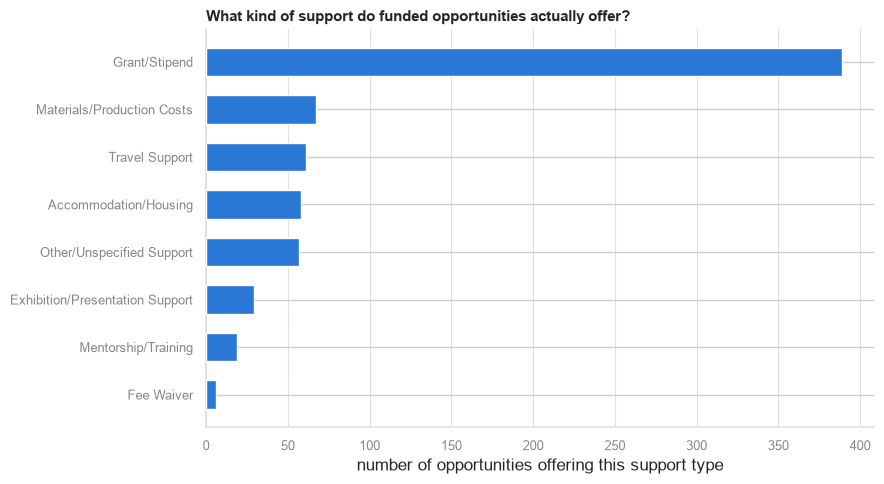

39% of opportunities with any funding info bundle more than one type of support (e.g. a stipend plus travel or accommodation) — 'funded' is rarely just a cash figure.


In [284]:
funding_components = df["funding_components"].apply(ast.literal_eval)
components_flat = pd.json_normalize(funding_components.explode().dropna().tolist())

category_counts = components_flat["category"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(category_counts.index[::-1], category_counts.values[::-1], color=CATEGORICAL[0], height=0.6, zorder=3)
ax.set_title("What kind of support do funded opportunities actually offer?", loc="left", fontsize=11, fontweight="bold")
ax.set_xlabel("number of opportunities offering this support type")
style_axis(ax, horizontal=True)
plt.tight_layout()
plt.show()

has_any_funding = funding_components.apply(len) > 0
bundled_share = (funding_components[has_any_funding].apply(len) > 1).mean()
print(f"{bundled_share:.0%} of opportunities with any funding info bundle more than one type of "
      f"support (e.g. a stipend plus travel or accommodation) — 'funded' is rarely just a cash figure.")

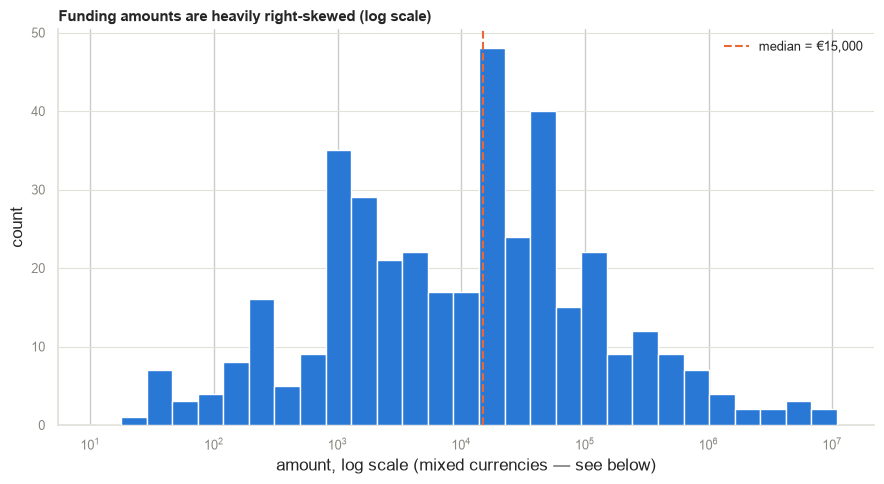

Largest single figure extracted: 10,920,000 EUR (Grant/Stipend). The pipeline's own extracted note on this row reads: "total programme budget / global available amount, not per applicant" — a good reminder to read extracted numbers in context rather than at face value.


In [285]:
import numpy as np

amounts = components_flat["amount_max"].dropna().astype(float)
amounts_positive = amounts[amounts > 0]
log_bins = np.logspace(np.log10(amounts_positive.min()), np.log10(amounts_positive.max()), 30)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(amounts_positive, bins=log_bins, color=CATEGORICAL[0], zorder=3)
ax.set_xscale("log")
ax.axvline(amounts_positive.median(), color=CATEGORICAL[1], linewidth=1.5, linestyle="--", zorder=4,
           label=f"median = €{amounts_positive.median():,.0f}")
ax.set_title("Funding amounts are heavily right-skewed (log scale)", loc="left", fontsize=11, fontweight="bold")
ax.set_xlabel("amount, log scale (mixed currencies — see below)")
ax.set_ylabel("count")
ax.legend(frameon=False, fontsize=9)
style_axis(ax)
plt.tight_layout()
plt.show()

top_amount = components_flat.loc[components_flat["amount_max"].astype(float).idxmax()]
print(f"Largest single figure extracted: {top_amount['amount_max']:,.0f} {top_amount.get('currency', '?')} "
      f"({top_amount['category']}). The pipeline's own extracted note on this row reads: "
      f"\"{top_amount.get('note', '')}\" — a good reminder to read extracted numbers in context "
      f"rather than at face value.")

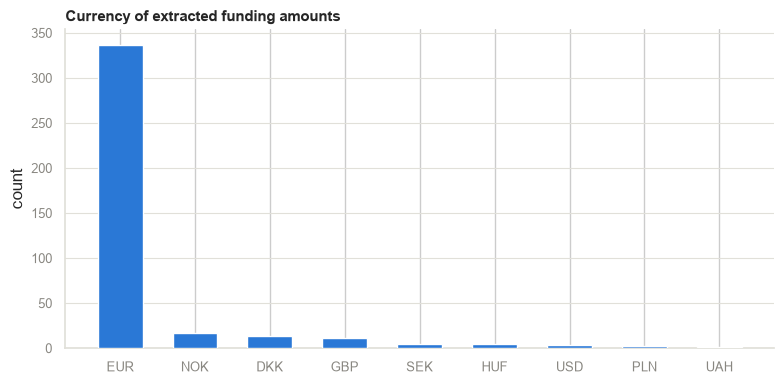

In [286]:
currency_counts = components_flat["currency"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(currency_counts.index, currency_counts.values, color=CATEGORICAL[0], width=0.6, zorder=3)
ax.set_title("Currency of extracted funding amounts", loc="left", fontsize=11, fontweight="bold")
ax.set_ylabel("count")
style_axis(ax)
plt.tight_layout()
plt.show()

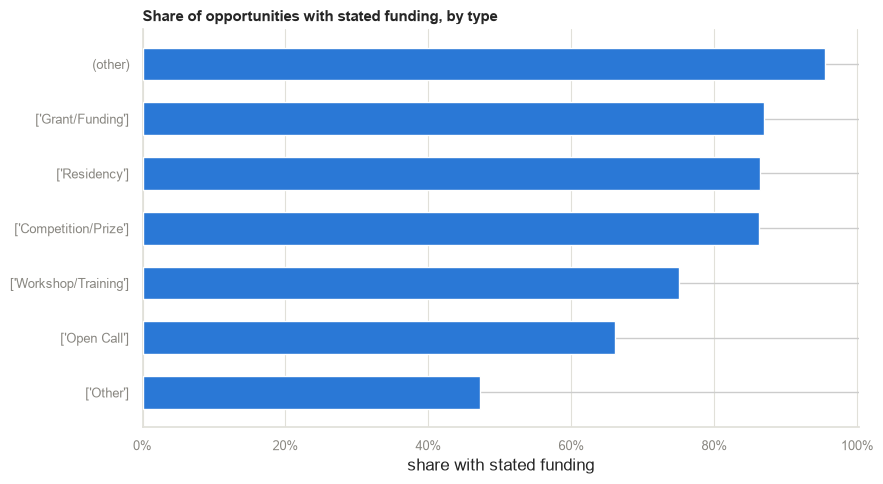

In [287]:
top_types = exploration_df["opportunity_type_canonical"].value_counts().head(6).index
type_bucketed = exploration_df["opportunity_type_canonical"].where(
    exploration_df["opportunity_type_canonical"].isin(top_types), "(other)"
)
has_funding = exploration_df["funding"].notna() & (exploration_df["funding"].astype(str).str.strip() != "")

funded_share_by_type = has_funding.groupby(type_bucketed).mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(funded_share_by_type.index[::-1], funded_share_by_type.values[::-1], color=CATEGORICAL[0], height=0.6, zorder=3)
ax.set_title("Share of opportunities with stated funding, by type", loc="left", fontsize=11, fontweight="bold")
ax.set_xlabel("share with stated funding")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
style_axis(ax, horizontal=True)
plt.tight_layout()
plt.show()

**Funding, in short:** about **39%** of funded opportunities bundle more than one kind of support (grant + travel + accommodation, say), amounts span several orders of magnitude (median ≈ €15,000; the extracted max of €10.92M turned out — per the pipeline's own note — to be a *total programme budget*, not a per-applicant figure, a useful caution about reading extracted numbers in context), and how "fundable" a call looks depends heavily on its type: Grant/Funding, Residency and Competition/Prize calls state funding **~86–87%** of the time, Open Calls only **66%**, and the generic "Other" bucket a mere **47%**. Type is doing real predictive work here — which is exactly the kind of structured signal the eligibility engine downstream can lean on. What it *can't* lean on is covered next.

---

## Act III — Why does this need NLP?

Everything above leaned on *structured* fields — columns an extraction pipeline already pulled out, cleaned and canonicalized. This last section asks the opposite question: how much eligibility information is genuinely locked inside free text (`requirements_text`), too variable and too entangled to read off a structured column? That gap is what RQ1's classifier is built to close.

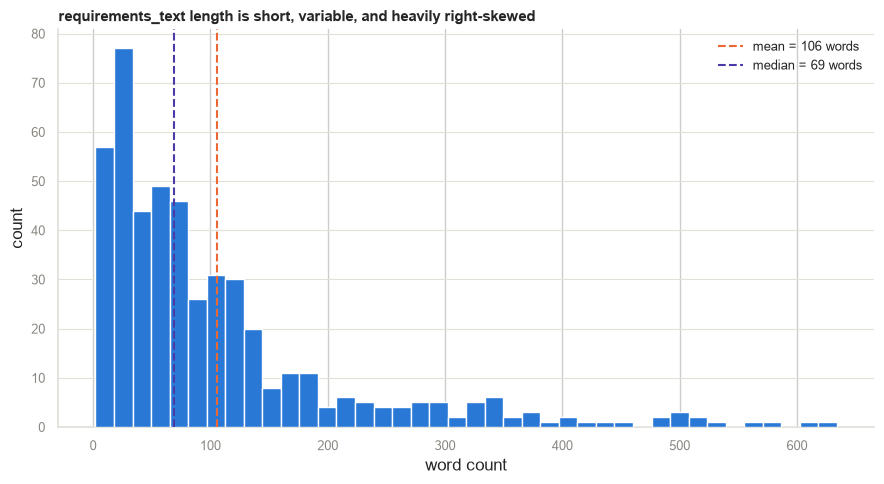

Range: 2-634 words. A 2-word entry and a 634-word entry are both single rows in the same column — a fixed-field lookup can't treat those consistently, but a classifier reading the sentence itself can.


In [288]:
word_counts = exploration_df["requirements_text_en"].fillna("").str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(word_counts, bins=40, color=CATEGORICAL[0], zorder=3)
ax.axvline(word_counts.mean(), color=CATEGORICAL[1], linewidth=1.5, linestyle="--", zorder=4,
           label=f"mean = {word_counts.mean():.0f} words")
ax.axvline(word_counts.median(), color=CATEGORICAL[6], linewidth=1.5, linestyle="--", zorder=4,
           label=f"median = {word_counts.median():.0f} words")
ax.set_title("requirements_text length is short, variable, and heavily right-skewed", loc="left",
             fontsize=11, fontweight="bold")
ax.set_xlabel("word count")
ax.set_ylabel("count")
ax.legend(frameon=False, fontsize=9)
style_axis(ax)
plt.tight_layout()
plt.show()

print(f"Range: {word_counts.min():.0f}-{word_counts.max():.0f} words. A 2-word entry and a "
      f"634-word entry are both single rows in the same column — a fixed-field lookup can't "
      f"treat those consistently, but a classifier reading the sentence itself can.")

/var/folders/60/p84z97d51rz4wdn4800x9x1r0000gn/T/ipykernel_65433/1996277751.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box = ax.boxplot(grouped, vert=False, patch_artist=True, showfliers=False, widths=0.55)


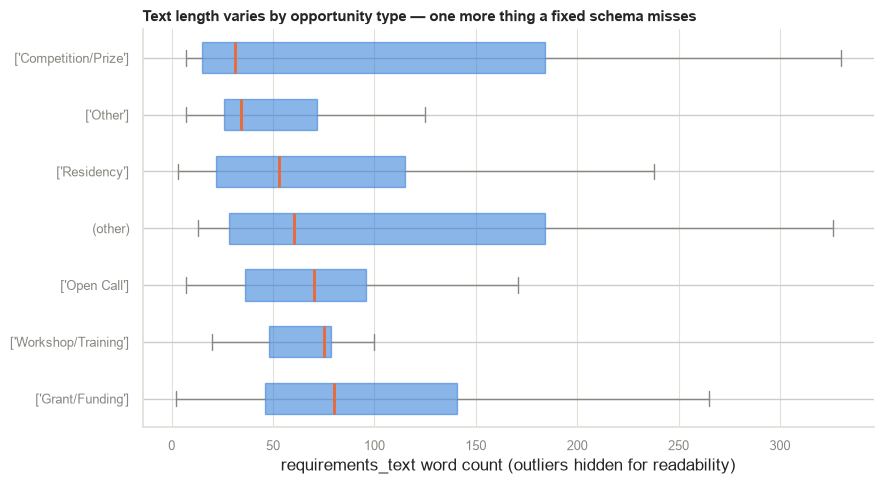

In [289]:
order = word_counts.groupby(type_bucketed).median().sort_values(ascending=False).index
grouped = [word_counts[type_bucketed == t].values for t in order]

fig, ax = plt.subplots(figsize=(9, 5))
box = ax.boxplot(grouped, vert=False, patch_artist=True, showfliers=False, widths=0.55)
for patch in box["boxes"]:
    patch.set_facecolor(CATEGORICAL[0])
    patch.set_alpha(0.55)
    patch.set_edgecolor(CATEGORICAL[0])
for element in ("whiskers", "caps"):
    for line in box[element]:
        line.set_color(MUTED_INK)
for median in box["medians"]:
    median.set_color(CATEGORICAL[1])
    median.set_linewidth(2)
ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels(order)
ax.set_xlabel("requirements_text word count (outliers hidden for readability)")
ax.set_title("Text length varies by opportunity type — one more thing a fixed schema misses",
             loc="left", fontsize=11, fontweight="bold")
style_axis(ax, horizontal=True)
plt.tight_layout()
plt.show()

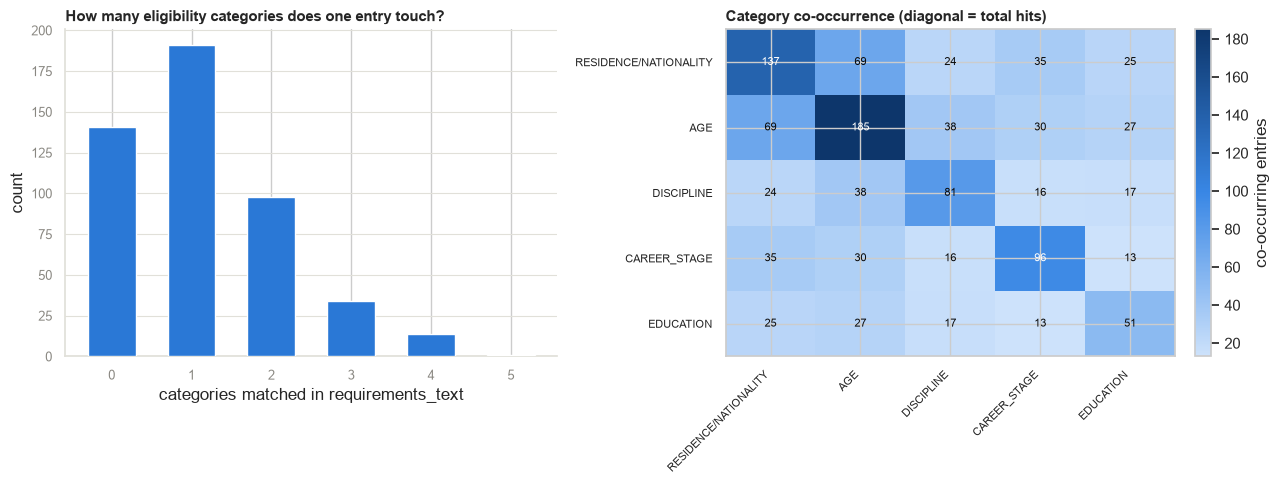

31% of entries hit 2+ eligibility categories in the same sentence — real overlap, not a rare edge case, which is why the annotation scheme allows multi-label where it's trivial rather than forcing every span into one bucket.


In [290]:
# Reuses ELIGIBILITY_KEYWORDS and text_lower from the keyword-hit cell above.
match_counts = pd.DataFrame(
    {label: text_lower.str.contains("|".join(keywords), regex=True) for label, keywords in ELIGIBILITY_KEYWORDS.items()}
)
n_categories_hit = match_counts.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hit_dist = n_categories_hit.value_counts().sort_index()
axes[0].bar(hit_dist.index.astype(str), hit_dist.values, color=CATEGORICAL[0], width=0.6, zorder=3)
axes[0].set_title("How many eligibility categories does one entry touch?", loc="left", fontsize=11, fontweight="bold")
axes[0].set_xlabel("categories matched in requirements_text")
axes[0].set_ylabel("count")
style_axis(axes[0])

cooc = match_counts.astype(int).T.dot(match_counts.astype(int))
im = axes[1].imshow(cooc.values, cmap=SEQUENTIAL_BLUE, aspect="auto")
axes[1].set_xticks(range(len(cooc.columns)))
axes[1].set_xticklabels(cooc.columns, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(len(cooc.index)))
axes[1].set_yticklabels(cooc.index, fontsize=8)
axes[1].set_title("Category co-occurrence (diagonal = total hits)", loc="left", fontsize=11, fontweight="bold")
for i in range(cooc.shape[0]):
    for j in range(cooc.shape[1]):
        val = cooc.values[i, j]
        axes[1].text(j, i, val, ha="center", va="center", fontsize=8,
                     color="white" if val > cooc.values.max() * 0.5 else "#0b0b0b")
fig.colorbar(im, ax=axes[1], label="co-occurring entries", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

multi_label_share = (n_categories_hit >= 2).mean()
print(f"{multi_label_share:.0%} of entries hit 2+ eligibility categories in the same sentence — "
      f"real overlap, not a rare edge case, which is why the annotation scheme allows multi-label "
      f"where it's trivial rather than forcing every span into one bucket.")

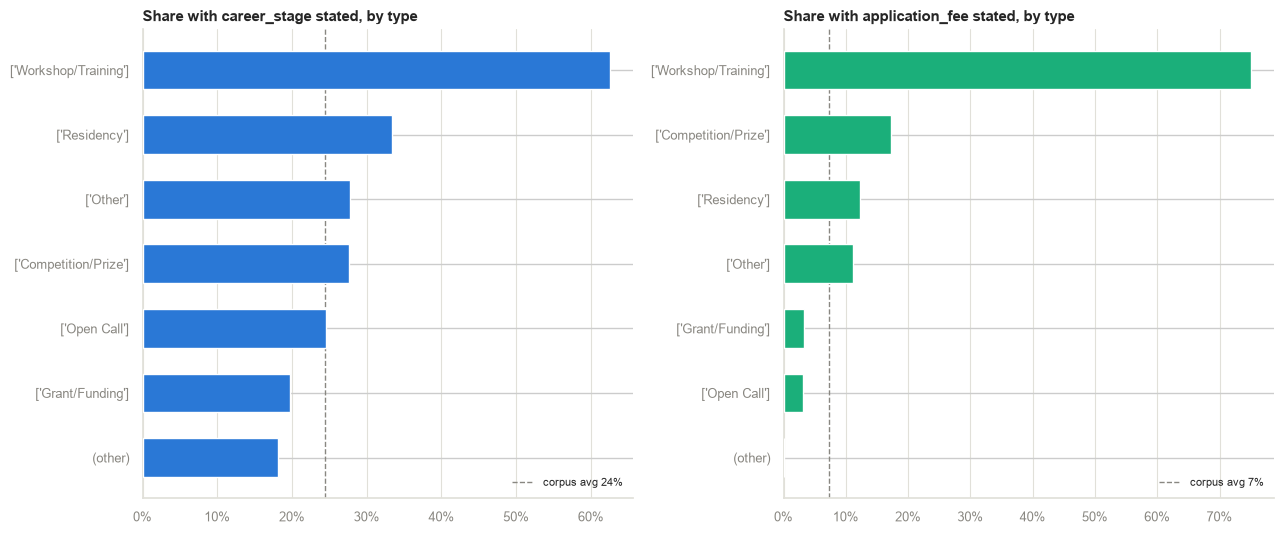

career_stage is stated for only 24% of the corpus overall; application_fee for only 7%. Neither is missing at random — both track opportunity type (Workshop/Training states both far more often than Grant/Funding or the '(other)' bucket) — which is exactly the kind of structure a plain field-presence check can't distinguish from 'this call simply has no requirement.'


In [291]:
career_stage_stated = exploration_df["career_stage_canonical"] != "[]"
fee_stated = exploration_df["application_fee_has_fee"].notna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, series, label, color in (
    (axes[0], career_stage_stated, "career_stage stated", CATEGORICAL[0]),
    (axes[1], fee_stated, "application_fee stated", CATEGORICAL[2]),
):
    share_by_type = series.groupby(type_bucketed).mean().sort_values(ascending=False)
    ax.barh(share_by_type.index[::-1], share_by_type.values[::-1], color=color, height=0.6, zorder=3)
    ax.axvline(series.mean(), color=MUTED_INK, linewidth=1, linestyle="--", zorder=2,
               label=f"corpus avg {series.mean():.0%}")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.set_title(f"Share with {label}, by type", loc="left", fontsize=11, fontweight="bold")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
    style_axis(ax, horizontal=True)

plt.tight_layout()
plt.show()

print(f"career_stage is stated for only {career_stage_stated.mean():.0%} of the corpus overall; "
      f"application_fee for only {fee_stated.mean():.0%}. Neither is missing at random — both track "
      f"opportunity type (Workshop/Training states both far more often than Grant/Funding or the "
      f"'(other)' bucket) — which is exactly the kind of structure a plain field-presence check "
      f"can't distinguish from 'this call simply has no requirement.'")

**The case for RQ1, in one paragraph:** structured extraction gets you a long way — discipline, country, type and funding are reliably populated and already power the descriptive charts above. But the two structured fields most directly tied to *eligibility*, `career_stage` and `application_fee`, are populated for only **24%** and **7%** of the corpus, and that gap is structural, not random — it tracks opportunity type, which means a naive rule ("if the field is empty, there's no requirement") would be systematically wrong in a predictable direction. Meanwhile `requirements_text` itself is short, highly variable in length (2–634 words), and **31%** of entries pack two or more eligibility categories into the same sentence. That combination — sparse structured coverage, dense and overlapping free text — is precisely the case for a classifier over `requirements_text` rather than a lookup over columns. It's also why the eligibility *engine* downstream stays plain deterministic rule-matching once the classifier has done the extraction: the ambiguity lives in reading the text, not in applying the rule once it's been read.